# Chapter 5 project - Explaining startup success (solution)

**Goal.** Given ~470 startups described by their founders, funding, product and team, build a
classifier for *success vs failure* and - the point of this chapter - **explain it**: which
features drive the prediction, how they act, and why one particular startup is predicted to fail.

We walk the whole interpretability toolbox from the three lectures:

- **Deck 1 (glass box):** logistic-regression coefficients / odds ratios, Lasso selection, a single readable tree, and a forest's (biased) impurity importance.
- **Deck 2 (model-agnostic):** permutation feature importance (PFI), partial dependence (PDP) and ICE.
- **Deck 3 (attribution):** SHAP (waterfall / bar / beeswarm / dependence), LIME, and counterfactuals (DiCE).

Along the way this dataset teaches three of the chapter's hardest lessons for free:
**data leakage** (features that leak the outcome), **important != causal**, and
**importance is method-dependent** (the four methods disagree).

> Data: `Startup_Success/` (from Metricam/Internship_tasks). It is deliberately messy - a realistic
> audit, not a toy.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import roc_auc_score, classification_report
import re
import lightgbm as lgb
import optuna

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
SEED = 509
np.random.seed(SEED)

# house palette: blue = success, red = failure, orange = accent (Armenian-flag colours)
BLUE, RED, ORANGE = "#0033A0", "#D90012", "#F2A800"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10})
%matplotlib inline

DATA = "Startup_Success/data.csv"
TARGET = "Dependent-Company Status"


def shorten(c, n=38):
    """Compact a long column name for plot labels."""
    c = c.replace("Survival through recession, based on existence of the company through recession times",
                  "recession_survival")
    c = (c.replace("Number of ", "n_").replace("Percent_skill_", "skill_")
          .replace(" organizations", "").replace("for Founders and Co-founders", "(founders)"))
    return c if len(c) <= n else c[:n - 3] + "..."

C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. First look

The file is not even UTF-8 (it has Windows-1252 bytes), so we read it as `latin-1` - the first of
many small data-quality tells.

In [2]:
raw = pd.read_csv(DATA, encoding="latin-1")
print("shape:", raw.shape)
print("target:", TARGET)
raw.head(3)

shape: (472, 116)
target: Dependent-Company Status


,Company_Name,Dependent-Company Status,year of founding,Age of company in years,Internet Activity Score,Short Description of company profile,Industry of company,Focus functions of company,Investors,Employee Count,...,Percent_skill_Data Science,Percent_skill_Business Strategy,Percent_skill_Product Management,Percent_skill_Sales,Percent_skill_Domain,Percent_skill_Law,Percent_skill_Consulting,Percent_skill_Finance,Percent_skill_Investment,Renown score
0,Company1,Success,No Info,No Info,-1.0,Video distribution,NaN,operation,KPCB Holdings|Draper Fisher Jurvetson (DFJ)|Kl...,3.0,...,0,0,0,0,0,0,0,0,0,0
1,Company2,Success,2011,3,125.0,NaN,Market Research|Marketing|Crowdfunding,"Marketing, sales",NaN,NaN,...,8.823529412,21.76470588,10.88235294,2.941176471,0,0,0,0,0,8
2,Company3,Success,2011,3,455.0,Event Data Analytics API,Analytics|Cloud Computing|Software Development,operations,TechStars|Streamlined Ventures|Amplify Partner...,14.0,...,3.846153846,17.09401709,9.401709402,0,2.777777778,0,0,0,0,9


In [3]:
# how many columns are numeric vs text as loaded?
print(raw.dtypes.value_counts())
print("\n108 of 116 columns arrive as 'object' - most are Yes/No or categorical, but many are really")
print("numbers polluted by the literal string 'No Info'. We fix that in the cleaning section.")

object     108
float64      5
int64        3
Name: count, dtype: int64

108 of 116 columns arrive as 'object' - most are Yes/No or categorical, but many are really
numbers polluted by the literal string 'No Info'. We fix that in the cleaning section.


## 2. The target

`Dependent-Company Status` is the outcome: **Success** or **Failed**. It is moderately imbalanced
(~65% success), so we will watch AUC and use `class_weight="balanced"`, not raw accuracy.

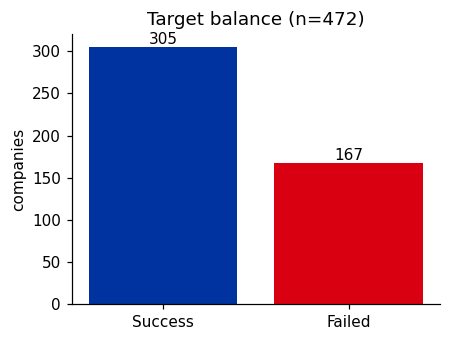

success rate: 0.646


In [4]:
counts = raw[TARGET].value_counts()
fig, ax = plt.subplots(figsize=(4.2, 3.2))
bars = ax.bar(counts.index, counts.values, color=[BLUE, RED])
ax.bar_label(bars)
ax.set_ylabel("companies"); ax.set_title(f"Target balance (n={len(raw)})")
plt.tight_layout(); plt.show()
print("success rate:", round((raw[TARGET] == "Success").mean(), 3))

## 3. Data-quality audit (heavy EDA)

Before any model we look hard at *how broken* the data is. Three problems dominate:
**missing values hidden as text**, **inconsistent categories**, and **numbers stored as strings**.

columns with >30% missing: 14 of 116  |  >50%: 5


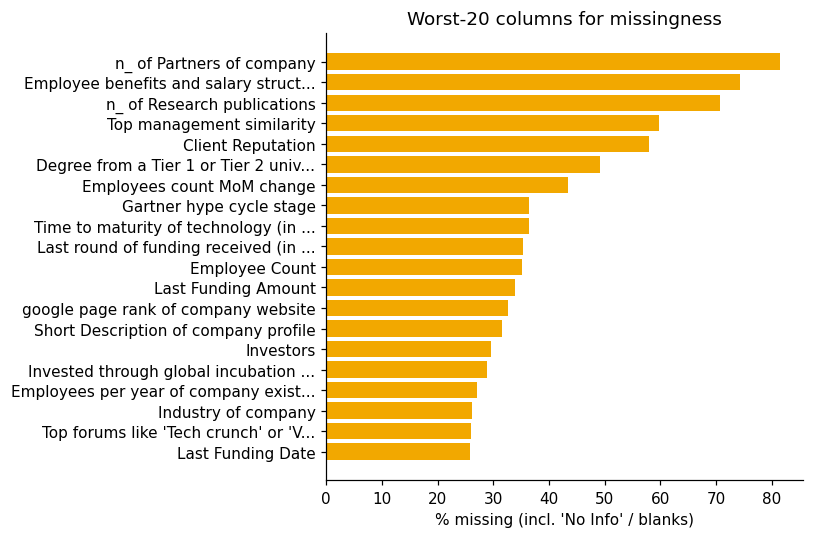

In [5]:
# 3a. Missingness is hidden behind literal tokens like "No Info" and blanks, not real NaN.
MISS_TOKENS = {"no info", "", "nan", "na", "n/a", "none", "unknown amount"}


def missing_mask(col):
    s = raw[col].astype(str).str.strip().str.lower()
    return raw[col].isna() | s.isin(MISS_TOKENS)


missrate = pd.Series({c: missing_mask(c).mean() for c in raw.columns}).sort_values(ascending=False)
print(f"columns with >30% missing: {(missrate > 0.30).sum()} of {raw.shape[1]}  |  >50%: {(missrate > 0.50).sum()}")

top = missrate.head(20)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh([shorten(c) for c in top.index][::-1], (top.values * 100)[::-1], color=ORANGE)
ax.set_xlabel("% missing (incl. 'No Info' / blanks)"); ax.set_title("Worst-20 columns for missingness")
plt.tight_layout(); plt.show()

In [6]:
# 3b. Inconsistent category spellings/case - the same value written several ways.
for c in ["Has the team size grown", "Local or global player", "Focus functions of company"]:
    print(c, "->", list(raw[c].dropna().astype(str).str.strip().value_counts().head(5).index))
print("\n'yes'/'Yes', 'local'/'Local' etc. must be case-folded or they become separate categories.")

Has the team size grown -> ['No', 'yes', 'Yes', 'YES', 'No Info']
Local or global player -> ['Local', 'local', 'Global', 'global', 'GLOBAL']
Focus functions of company -> ['Operations', 'Marketing', 'analytics', 'operation', 'marketing']

'yes'/'Yes', 'local'/'Local' etc. must be case-folded or they become separate categories.


In [7]:
# 3c. Numbers stored as strings because 'No Info' contaminates the column.
demo = raw["Employee Count"].value_counts(dropna=False).head(6)
print("Employee Count (an integer feature) - note the string 'No Info' mixed with numbers:")
print(demo)

Employee Count (an integer feature) - note the string 'No Info' mixed with numbers:
Employee Count
NaN    166
0.0     23
1.0     18
6.0     17
4.0     16
5.0     13
Name: count, dtype: int64


## 4. Distributions of the numeric features

A quick grid of the numeric columns (after coercing away the text tokens). Heavy right-skew on the
money/size columns is typical of startup data.

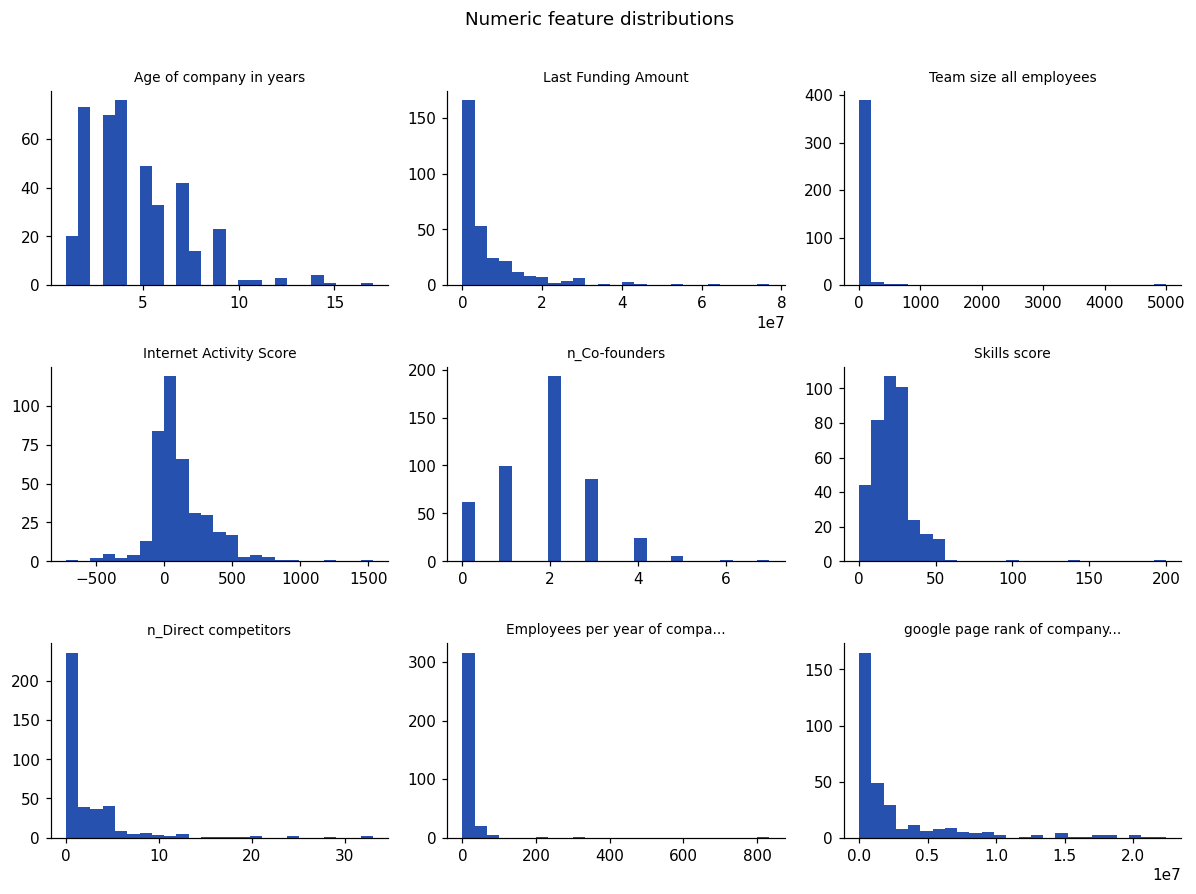

In [8]:
def to_num(col):
    s = raw[col].astype(str).str.strip()
    s = s.mask(s.str.lower().isin(MISS_TOKENS))
    return pd.to_numeric(s, errors="coerce")


num_show = ["Age of company in years", "Last Funding Amount", "Team size all employees",
            "Internet Activity Score", "Number of Co-founders", "Skills score",
            "Number of Direct competitors", "Employees per year of company existence",
            "google page rank of company website"]
fig, axes = plt.subplots(3, 3, figsize=(11, 8))
for ax, c in zip(axes.ravel(), num_show):
    ax.hist(to_num(c).dropna(), bins=25, color=BLUE, alpha=0.85)
    ax.set_title(shorten(c, 30), fontsize=9)
fig.suptitle("Numeric feature distributions", y=1.01)
plt.tight_layout(); plt.show()

## 5. How features relate to the outcome

Simple bivariate views: does the feature separate success from failure at all? A few examples that
a founder would care about.

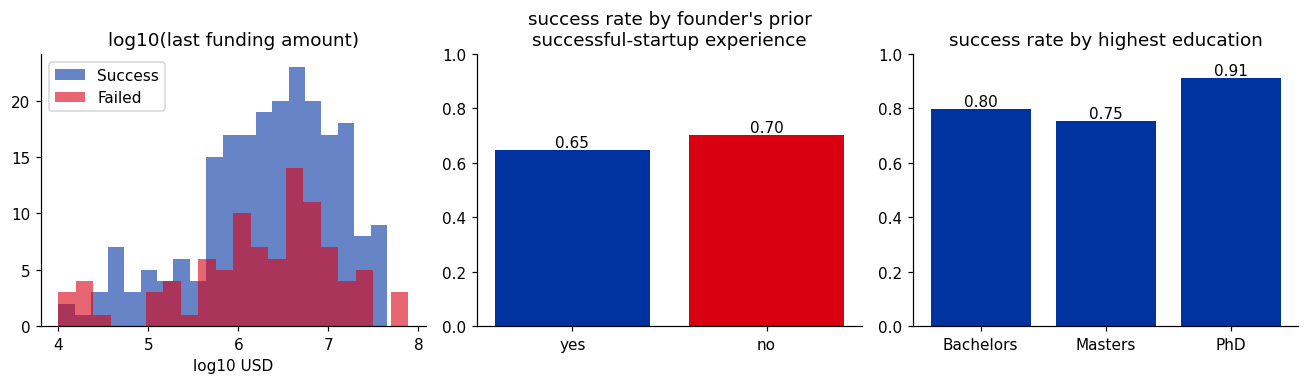

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
# 5a. funding amount by outcome (log scale)
d = pd.DataFrame({"amt": to_num("Last Funding Amount"), "y": raw[TARGET]}).dropna()
for lbl, col in [("Success", BLUE), ("Failed", RED)]:
    axes[0].hist(np.log10(d.loc[d.y == lbl, "amt"].clip(lower=1)), bins=20, alpha=0.6, label=lbl, color=col)
axes[0].set_title("log10(last funding amount)"); axes[0].set_xlabel("log10 USD"); axes[0].legend()
# 5b. success rate by 'part of successful startups in past'
sr = raw.groupby(raw["Have been part of successful startups in the past?"].astype(str).str.strip().str.lower())[TARGET]
sr = sr.apply(lambda s: (s == "Success").mean()).reindex(["yes", "no"])
b = axes[1].bar(["yes", "no"], sr.values, color=[BLUE, RED]); axes[1].bar_label(b, fmt="%.2f")
axes[1].set_ylim(0, 1); axes[1].set_title("success rate by founder's prior\nsuccessful-startup experience")
# 5c. success rate by highest education
ed = raw.groupby(raw["Highest education"].astype(str).str.strip())[TARGET]
ed = ed.apply(lambda s: (s == "Success").mean()).reindex(["Bachelors", "Masters", "PhD"]).dropna()
b = axes[2].bar(ed.index, ed.values, color=BLUE); axes[2].bar_label(b, fmt="%.2f")
axes[2].set_ylim(0, 1); axes[2].set_title("success rate by highest education")
plt.tight_layout(); plt.show()

## 6. Correlation structure

The chapter's running warning is that **correlated features muddy every importance method**. This
dataset is full of correlated groups: `year of founding` vs `Age of company`, the three
`Fortune 100/500/1000` flags, and the 15 `Percent_skill_*` columns. We will see these split and
destabilise the importances later.

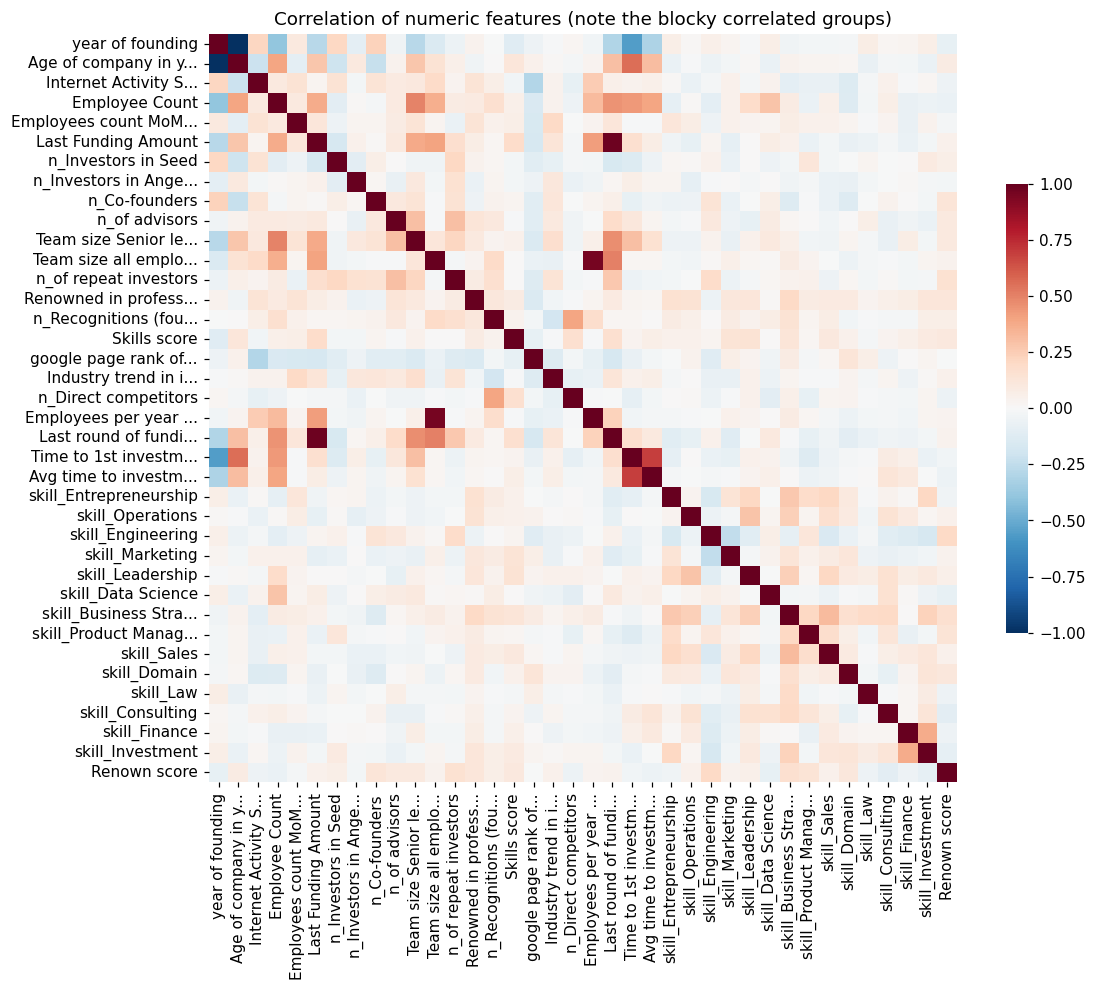

In [10]:
num_cols = [c for c in raw.columns if to_num(c).notna().mean() > 0.5
            and to_num(c).nunique() > 5]
corr = pd.DataFrame({c: to_num(c) for c in num_cols}).corr()
corr.columns = [shorten(c, 22) for c in corr.columns]; corr.index = corr.columns
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Correlation of numeric features (note the blocky correlated groups)")
plt.tight_layout(); plt.show()

## 7. Leakage audit - the most important EDA step here

A startup dataset is a minefield for **target leakage**: features recorded *after* we already know
the company survived. The clearest one is literally named for it.

In [11]:
lk = "Survival through recession, based on existence of the company through recession times"
ct = pd.crosstab(raw[lk].astype(str).str.strip(), raw[TARGET])
print(ct)
print("\n'No' (did not survive the recession) => 31 Failed, 0 Success: a perfect predictor of failure.")
print("This can only be known AFTER the outcome. It is leakage, not a driver.")

Dependent-Company Status                            Failed  Success
Survival through recession, based on existence ...                 
No                                                      31        0
No Info                                                 91        7
Not Applicable                                          35      233
Yes                                                     10       65

'No' (did not survive the recession) => 31 Failed, 0 Success: a perfect predictor of failure.
This can only be known AFTER the outcome. It is leakage, not a driver.


It is not the only suspect. Several features are plausibly **post-hoc** - measured at data-collection
time, i.e. after success/failure was decided:

- `Internet Activity Score`, `google page rank of company website` (a dead company stops updating),
- `Number of Recognitions`, `Company awards`, `Top forums ... talking about the company`.

We will not hand-remove all of these (that needs domain sign-off). Instead we let **PFI and SHAP
surface which features the model leans on**, then judge. That auditing use is the whole point of
interpretability: *interpretability catches models that cheat.*

## 8. Cleaning

A single, documented function. Strategy:

1. drop identifiers / free text / dates (`Company_Name`, `Short Description`, `Investors`, dates, ...),
2. turn every missing token into `NaN` (but keep `Not Applicable` - it is a real level for the recession feature),
3. drop columns >55% missing (except the recession leak, kept for the audit),
4. per column: coerce to **numeric** if it parses, else map **Yes/No -> 1/0**, else map known **ordinals** (Low/Medium/High, ...), else **one-hot** low-cardinality nominals,
5. impute numeric/ordinal/binary with the median; one-hot the rest.

In [12]:
DROP_SUBSTR = ["Company_Name", "Short Description", "Investors", "Founding Date", "Funding Date",
               "Specialization of highest", "Industry of company", "Focus functions"]
ORD_MAPS = [
    {"low": 0, "medium": 1, "high": 2},
    {"small": 0, "medium": 1, "large": 2},
    {"bachelors": 0, "masters": 1, "phd": 2},
    {"nothing": 0, "low": 1, "medium": 2, "high": 3},
    {"0 to 2": 0, "2 to 5": 1, "5 to 10": 2, "10 to 15": 3, "15 to 20": 4},
]


def _norm(s):
    return s.astype(str).str.strip().str.lower()


def clean(df):
    df = df.copy()
    y = (df[TARGET].str.strip().str.lower() == "success").astype(int)
    df = df.drop(columns=[TARGET])
    df = df.drop(columns=[c for c in df.columns
                          if any(k.lower() in c.lower() for k in DROP_SUBSTR)])
    for c in df.columns:                                  # missing tokens -> NaN
        df[c] = df[c].astype(str).str.strip().mask(_norm(df[c]).isin(MISS_TOKENS) | df[c].isna())
    miss = df.isna().mean()
    df = df.drop(columns=[c for c in df.columns if miss[c] > 0.55 and "recession" not in c.lower()])

    kinds = {}
    for c in list(df.columns):
        nn = df[c].dropna()
        vals = set(_norm(nn.to_frame()[c]))
        if len(nn) and nn.astype(str).str.strip().str.match(r"^-?\d+(\.\d+)?$").mean() > 0.85:
            df[c] = pd.to_numeric(df[c].astype(str).str.strip(), errors="coerce"); kinds[c] = "num"
        elif vals <= {"yes", "no"}:
            df[c] = _norm(df[c]).map({"yes": 1, "no": 0}); kinds[c] = "bin"
        elif (m := next((m for m in ORD_MAPS if vals <= set(m)), None)) is not None:
            df[c] = _norm(df[c]).map(m); kinds[c] = "ord"
        elif nn.nunique() <= 12:
            kinds[c] = "nom"
        else:
            df = df.drop(columns=[c])
    numlike = [c for c, k in kinds.items() if k in ("num", "ord", "bin") and c in df.columns]
    nom = [c for c, k in kinds.items() if k == "nom" and c in df.columns]
    df[numlike] = df[numlike].apply(lambda s: s.fillna(s.median()))
    df = pd.get_dummies(df, columns=nom, dummy_na=False, dtype=float)
    return df, y, kinds


X, y, kinds = clean(raw)
print("clean feature matrix:", X.shape, "| success rate:", round(y.mean(), 3))
print("column kinds:", pd.Series(kinds).value_counts().to_dict())
print("NaNs remaining:", int(X.isna().sum().sum()))
print("\nNote: 472 rows but ~130 features (after one-hot). This is a small-n, high-p regime -")
print("importances will be noisy; we lean on error bars and read rankings, not exact values.")

clean feature matrix: (472, 134) | success rate: 0.646
column kinds: {'num': 39, 'bin': 35, 'nom': 13, 'ord': 11}
NaNs remaining: 0

Note: 472 rows but ~130 features (after one-hot). This is a small-n, high-p regime -
importances will be noisy; we lean on error bars and read rankings, not exact values.


## 9. Train / test split

Stratified 70/30. Every importance question below is answered on the **test** set (deck 2's rule).

In [13]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
print("train:", Xtr.shape, "test:", Xte.shape)

train: (330, 134) test: (142, 134)


## 10. Deck 1 - the glass boxes you can just read

### 10a. Logistic regression: coefficients and odds ratios
On standardised features, a coefficient is the log-odds change per +1 SD; `exp(coef)` is the odds
ratio. Sign = direction, magnitude = strength.

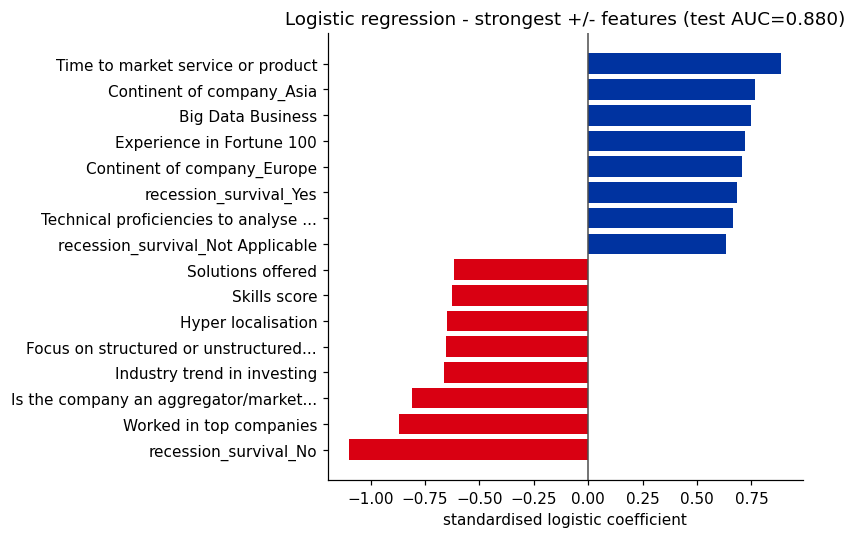

Read as odds ratios, e.g. top positive feature: Time to market service or product -> OR = 2.43


In [14]:
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced"))
logreg.fit(Xtr, ytr)
lr_auc = roc_auc_score(yte, logreg.predict_proba(Xte)[:, 1])
coef = pd.Series(logreg[-1].coef_[0], index=X.columns)
odds = np.exp(coef)
top = pd.concat([coef.sort_values().head(8), coef.sort_values().tail(8)])
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh([shorten(c) for c in top.index], top.values,
        color=[BLUE if v > 0 else RED for v in top.values])
ax.axvline(0, color="0.3", lw=1); ax.set_xlabel("standardised logistic coefficient")
ax.set_title(f"Logistic regression - strongest +/- features (test AUC={lr_auc:.3f})")
plt.tight_layout(); plt.show()
print("Read as odds ratios, e.g. top positive feature:",
      shorten(coef.idxmax()), "-> OR =", round(odds.max(), 2))

### 10b. Lasso (L1) logistic - the model selects its own features
L1 drives most coefficients to exactly zero; the survivors are the "selected" features.

In [15]:
lasso = make_pipeline(StandardScaler(),
                      LogisticRegression(penalty="l1", solver="liblinear", C=0.2,
                                         class_weight="balanced", max_iter=5000))
lasso.fit(Xtr, ytr)
nz = np.sum(lasso[-1].coef_[0] != 0)
kept = pd.Series(lasso[-1].coef_[0], index=X.columns)
kept = kept[kept != 0].abs().sort_values(ascending=False)
print(f"Lasso (C=0.2) keeps {nz}/{X.shape[1]} features. Top survivors:")
print([shorten(c) for c in kept.head(10).index])

Lasso (C=0.2) keeps 46/134 features. Top survivors:
['recession_survival_Not Applicable', 'recession_survival_Yes', 'Big Data Business', 'Focus on structured or unstructured...', 'n_Recognitions (founders)', 'Technical proficiencies to analyse ...', 'Continent of company_Asia', 'Continent of company_Europe', 'n_ Sales Support material', 'Focus on structured or unstructured...']


### 10c. A single tree you can read
Shallow enough to follow a root-to-leaf path as a rule.

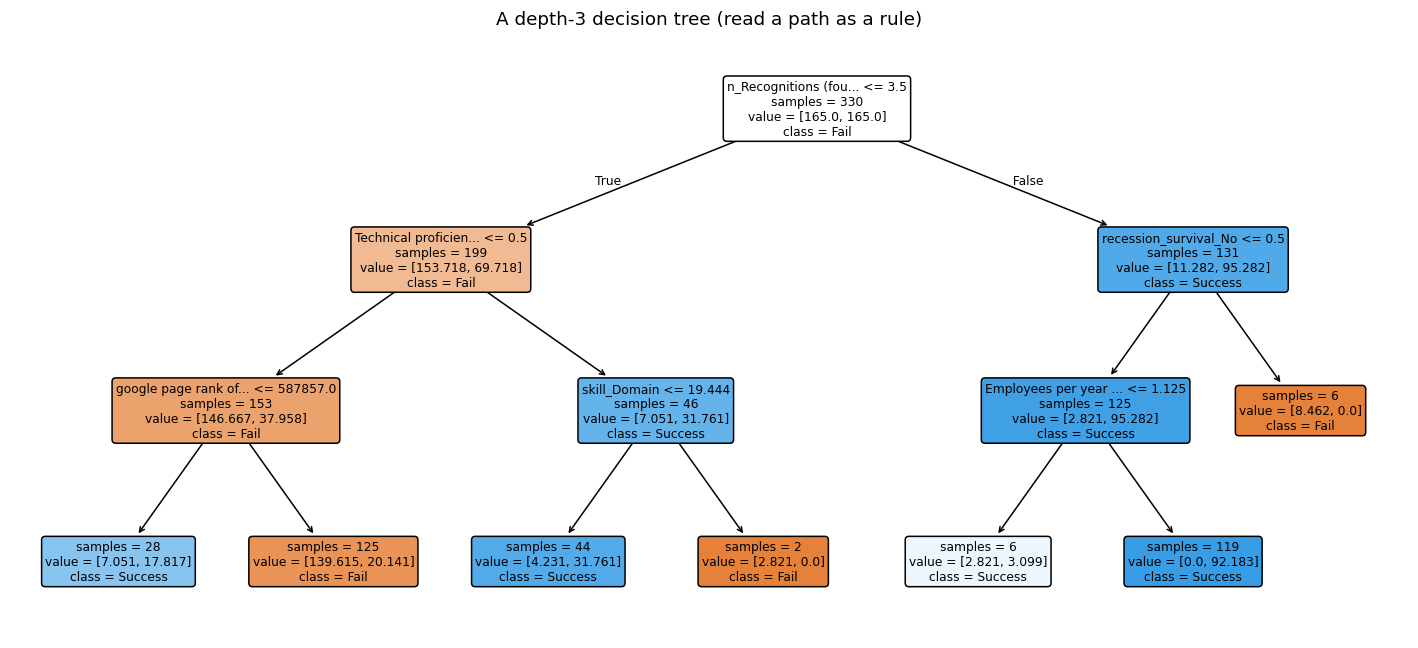

tree test AUC: 0.844


In [16]:
tree = DecisionTreeClassifier(max_depth=3, random_state=SEED, class_weight="balanced").fit(Xtr, ytr)
fig, ax = plt.subplots(figsize=(13, 6))
plot_tree(tree, feature_names=[shorten(c, 22) for c in X.columns], class_names=["Fail", "Success"],
          filled=True, rounded=True, impurity=False, fontsize=8, ax=ax)
ax.set_title("A depth-3 decision tree (read a path as a rule)")
plt.tight_layout(); plt.show()
print("tree test AUC:", round(roc_auc_score(yte, tree.predict_proba(Xte)[:, 1]), 3))

## 11. Deck 1 - a forest and its (biased) built-in importance

A random forest is far more accurate but unreadable; it still emits an impurity importance. That
number is **biased** toward high-cardinality / continuous features and **split across correlated**
ones - keep that in mind reading the bar.

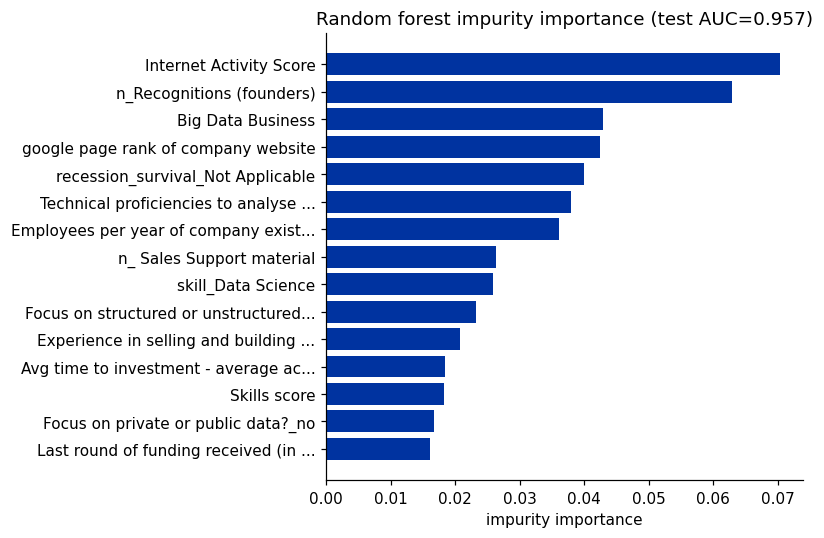

Forest AUC 0.957 vs logistic 0.880. That 0.9+ AUC is suspiciously high - hold that thought.


In [17]:
rf = RandomForestClassifier(n_estimators=400, random_state=SEED, class_weight="balanced", n_jobs=-1)
rf.fit(Xtr, ytr)
rf_auc = roc_auc_score(yte, rf.predict_proba(Xte)[:, 1])
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh([shorten(c) for c in imp.head(15).index][::-1], imp.head(15).values[::-1], color=BLUE)
ax.set_xlabel("impurity importance"); ax.set_title(f"Random forest impurity importance (test AUC={rf_auc:.3f})")
plt.tight_layout(); plt.show()
print(f"Forest AUC {rf_auc:.3f} vs logistic {lr_auc:.3f}. That 0.9+ AUC is suspiciously high - hold that thought.")

## 12. Deck 2 - permutation feature importance (PFI)

Model-agnostic: permute a feature on the **test** set and measure the drop in AUC. Error bars come
from repeated shuffles. This is our **leakage audit**: whatever the model leans on floats to the top.

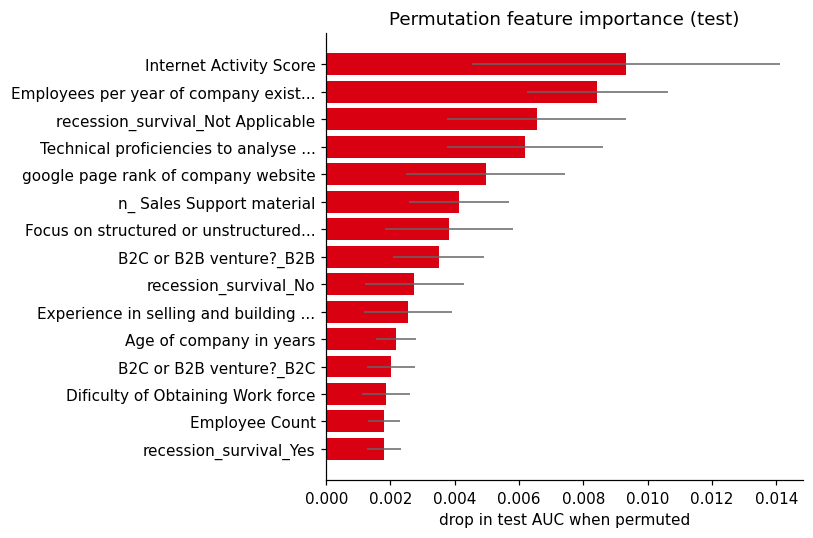

Leakage feature(s) among the PFI top: ['recession_survival_Not Applicable', 'recession_survival_No', 'recession_survival_Yes']
Also near the top: internet activity, page rank, recognitions - the post-hoc suspects from the audit.


In [18]:
r = permutation_importance(rf, Xte, yte, n_repeats=20, random_state=SEED, scoring="roc_auc")
pfi = pd.Series(r.importances_mean, index=X.columns)
err = pd.Series(r.importances_std, index=X.columns)
order = pfi.sort_values().tail(15).index
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh([shorten(c) for c in order], pfi[order].values, xerr=err[order].values,
        color=RED, error_kw=dict(ecolor="0.4", lw=1))
ax.set_xlabel("drop in test AUC when permuted"); ax.set_title("Permutation feature importance (test)")
plt.tight_layout(); plt.show()
leak_here = [shorten(c) for c in order[::-1] if "recession" in c.lower()]
print("Leakage feature(s) among the PFI top:", leak_here)
print("Also near the top: internet activity, page rank, recognitions - the post-hoc suspects from the audit.")

## 13. Deck 2 - feature effects: PDP and ICE

PFI says *how much*; PDP/ICE say *how*. We take a strong continuous feature and plot the average
effect (PDP) plus per-company ICE curves to expose heterogeneity the average hides.

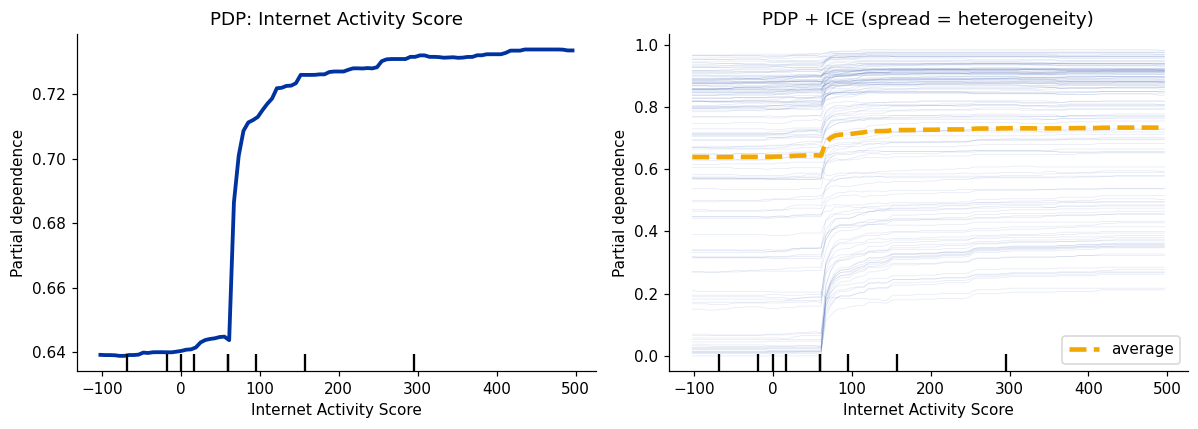

In [19]:
feat = imp.index[[i for i, c in enumerate(imp.index) if X[c].nunique() > 10][0]]  # top continuous
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
PartialDependenceDisplay.from_estimator(rf, Xte, [feat], ax=ax[0], line_kw=dict(color=BLUE, lw=2.5))
ax[0].set_title(f"PDP: {shorten(feat, 26)}")
PartialDependenceDisplay.from_estimator(rf, Xte, [feat], kind="both", ax=ax[1],
                                        ice_lines_kw=dict(color=BLUE, alpha=0.1),
                                        pd_line_kw=dict(color=ORANGE, lw=3))
ax[1].set_title("PDP + ICE (spread = heterogeneity)")
plt.tight_layout(); plt.show()

## 14. Remove the clear leak and refit

We drop the recession-survival columns (the one unambiguous leak) and refit. Watch what happens to
AUC.

In [20]:
safe_cols = [c for c in X.columns if "recession" not in c.lower()]
Xtr_s, Xte_s = Xtr[safe_cols], Xte[safe_cols]
rf_s = RandomForestClassifier(n_estimators=400, random_state=SEED, class_weight="balanced", n_jobs=-1)
rf_s.fit(Xtr_s, ytr)
rf_s_auc = roc_auc_score(yte, rf_s.predict_proba(Xte_s)[:, 1])
print(f"AUC with the leak: {rf_auc:.3f}   without the recession columns: {rf_s_auc:.3f}")
print("Barely moves - because leakage here is DISTRIBUTED across several post-hoc features, not one.")
print("Lesson: removing a single leaky column is not enough; you must audit the whole top of the ranking.")

AUC with the leak: 0.957   without the recession columns: 0.948
Barely moves - because leakage here is DISTRIBUTED across several post-hoc features, not one.
Lesson: removing a single leaky column is not enough; you must audit the whole top of the ranking.


## 15. A stronger model: LightGBM tuned with Bayesian optimization

The forest is fine, but gradient boosting usually wins on tabular data. We tune a **LightGBM** with
**Bayesian optimization** (Optuna's TPE sampler): rather than grid or random search, it uses the
scores of past trials to propose promising hyperparameters next, spending the budget where it helps.
We maximise **5-fold CV AUC** on the de-leaked training set.

One practical snag: LightGBM rejects feature names containing characters like `?`, `,`, `(`, so we
sanitise the names for the booster and keep a map back to the readable ones for the plots.

In [21]:
def lgbm_safe(cols):
    out, seen = [], {}
    for c in cols:
        s = re.sub(r"[^0-9A-Za-z]+", "_", c).strip("_") or "f"
        seen[s] = seen.get(s, -1) + 1
        out.append(s if seen[s] == 0 else f"{s}_{seen[s]}")
    return out


gnames = lgbm_safe(safe_cols)                    # LightGBM-safe feature names
back = dict(zip(gnames, safe_cols))              # sanitized -> original (for readable labels)
Xtr_g, Xte_g = Xtr_s.copy(), Xte_s.copy()
Xtr_g.columns = gnames; Xte_g.columns = gnames
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)


def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 600),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        num_leaves=trial.suggest_int("num_leaves", 15, 127),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 60),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10, log=True))
    m = lgb.LGBMClassifier(**params, random_state=SEED, class_weight="balanced", n_jobs=-1, verbose=-1)
    return cross_val_score(m, Xtr_g, ytr, cv=cv, scoring="roc_auc").mean()


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=30, show_progress_bar=False)
print(f"best 5-fold CV AUC: {study.best_value:.4f}  (over {len(study.trials)} Bayesian trials)")
print("best params:", {k: (round(v, 3) if isinstance(v, float) else v) for k, v in study.best_params.items()})

best = lgb.LGBMClassifier(**study.best_params, random_state=SEED, class_weight="balanced",
                          n_jobs=-1, verbose=-1).fit(Xtr_g, ytr)
gbm_auc = roc_auc_score(yte, best.predict_proba(Xte_g)[:, 1])
print(f"tuned LightGBM test AUC: {gbm_auc:.3f}")

best 5-fold CV AUC: 0.9708  (over 30 Bayesian trials)
best params: {'n_estimators': 266, 'learning_rate': 0.014, 'num_leaves': 16, 'max_depth': 11, 'min_child_samples': 28, 'subsample': 0.825, 'colsample_bytree': 0.826, 'reg_lambda': 0.004, 'reg_alpha': 3.655}
tuned LightGBM test AUC: 0.937


The Bayesian search history (running-best CV AUC) and a fair scoreboard of the de-leaked models.
Note the honest twist: tuning pushed the **CV** AUC high, but on the 142-row **test** set LightGBM is
within noise of the forest - on 472 rows you should not over-read a 0.01 AUC gap.

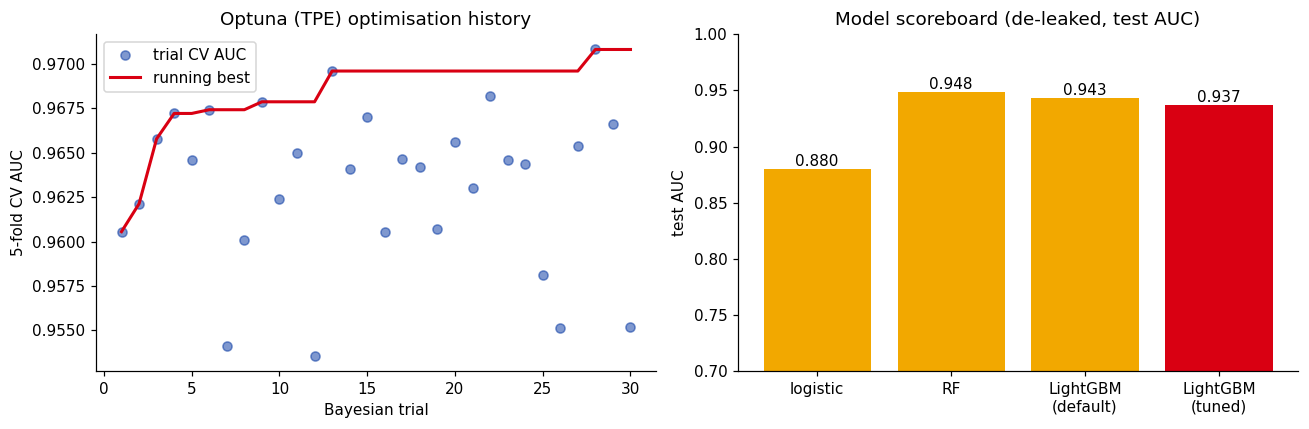

In [22]:
gbm0 = lgb.LGBMClassifier(random_state=SEED, class_weight="balanced", n_jobs=-1, verbose=-1).fit(Xtr_g, ytr)
gbm0_auc = roc_auc_score(yte, gbm0.predict_proba(Xte_g)[:, 1])
lr_safe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced")).fit(Xtr_s, ytr)
lr_safe_auc = roc_auc_score(yte, lr_safe.predict_proba(Xte_s)[:, 1])

vals = [t.value for t in study.trials]
running = np.maximum.accumulate(vals)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(1, len(vals) + 1), vals, "o", color=BLUE, alpha=0.5, label="trial CV AUC")
ax[0].plot(range(1, len(vals) + 1), running, color=RED, lw=2, label="running best")
ax[0].set_xlabel("Bayesian trial"); ax[0].set_ylabel("5-fold CV AUC")
ax[0].legend(); ax[0].set_title("Optuna (TPE) optimisation history")
board = pd.Series({"logistic": lr_safe_auc, "RF": rf_s_auc,
                   "LightGBM\n(default)": gbm0_auc, "LightGBM\n(tuned)": gbm_auc})
b = ax[1].bar(range(len(board)), board.values, color=[ORANGE, ORANGE, ORANGE, RED])
ax[1].set_xticks(range(len(board)), board.index); ax[1].set_ylim(0.7, 1.0)
ax[1].bar_label(b, fmt="%.3f"); ax[1].set_ylabel("test AUC")
ax[1].set_title("Model scoreboard (de-leaked, test AUC)")
plt.tight_layout(); plt.show()

## 16. Deck 3 - SHAP (on the tuned LightGBM)

SHAP splits each prediction into per-feature contributions that sum to it. **TreeSHAP** is exact and
fast for boosted trees - the canonical case - so we now explain the **tuned LightGBM**. We request
SHAP in **probability space** (with a small background sample) so the values sum to the predicted
probability, then read its four plots.

In [23]:
import shap
bg = shap.sample(Xtr_g, 100, random_state=SEED)          # background for probability-space SHAP
explainer = shap.TreeExplainer(best, bg, model_output="probability")
sv = explainer(Xte_g, check_additivity=False)
sv = sv[:, :, 1] if sv.values.ndim == 3 else sv          # positive (Success) class
sv.feature_names = [shorten(back[c]) for c in gnames]    # readable labels
print("SHAP Explanation (tuned LightGBM):", sv.values.shape)

SHAP Explanation (tuned LightGBM): (142, 131)


### 16a. Waterfall - one startup, fully explained
Start at the base value (average prediction) and add each feature's SHAP value to reach this
company's predicted probability.

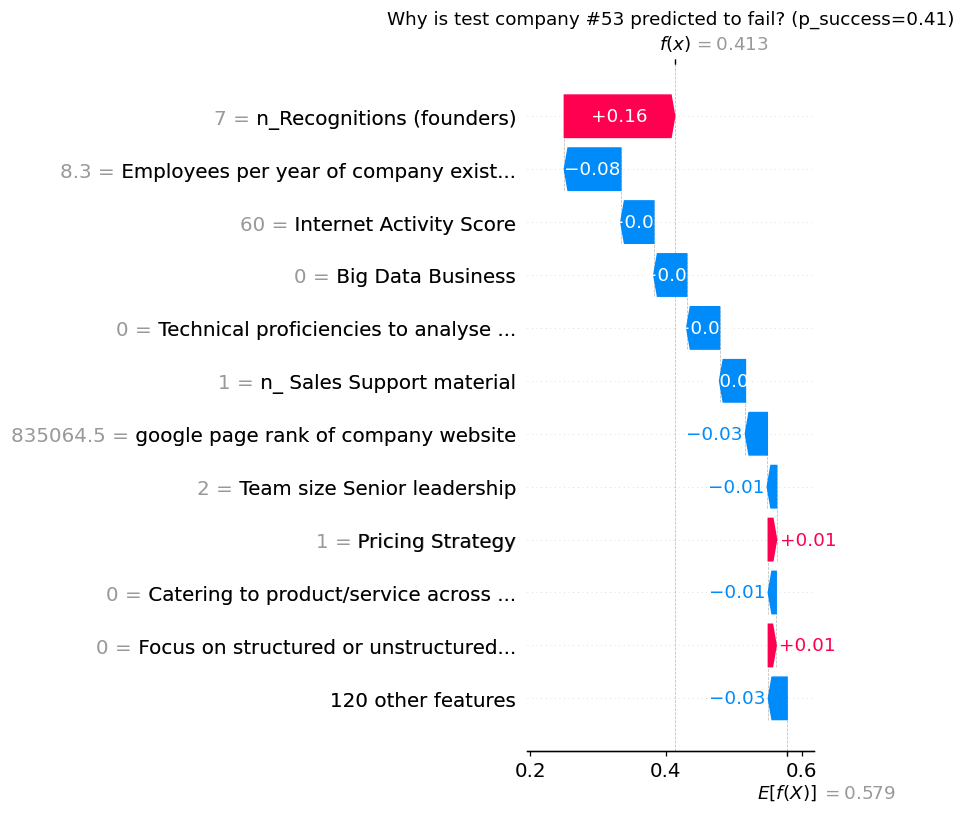

In [24]:
p_s = best.predict_proba(Xte_g)[:, 1]
fail_idx = np.where(p_s < 0.5)[0]
i = int(fail_idx[np.argmin(np.abs(p_s[fail_idx] - 0.42))])   # a clearly predicted-fail company, near enough to flip
shap.plots.waterfall(sv[i], max_display=12, show=False)
plt.title(f"Why is test company #{i} predicted to fail? (p_success={p_s[i]:.2f})")
plt.tight_layout(); plt.show()

### 16b. Bar - global importance (mean |SHAP|). Reads like the PFI bar.

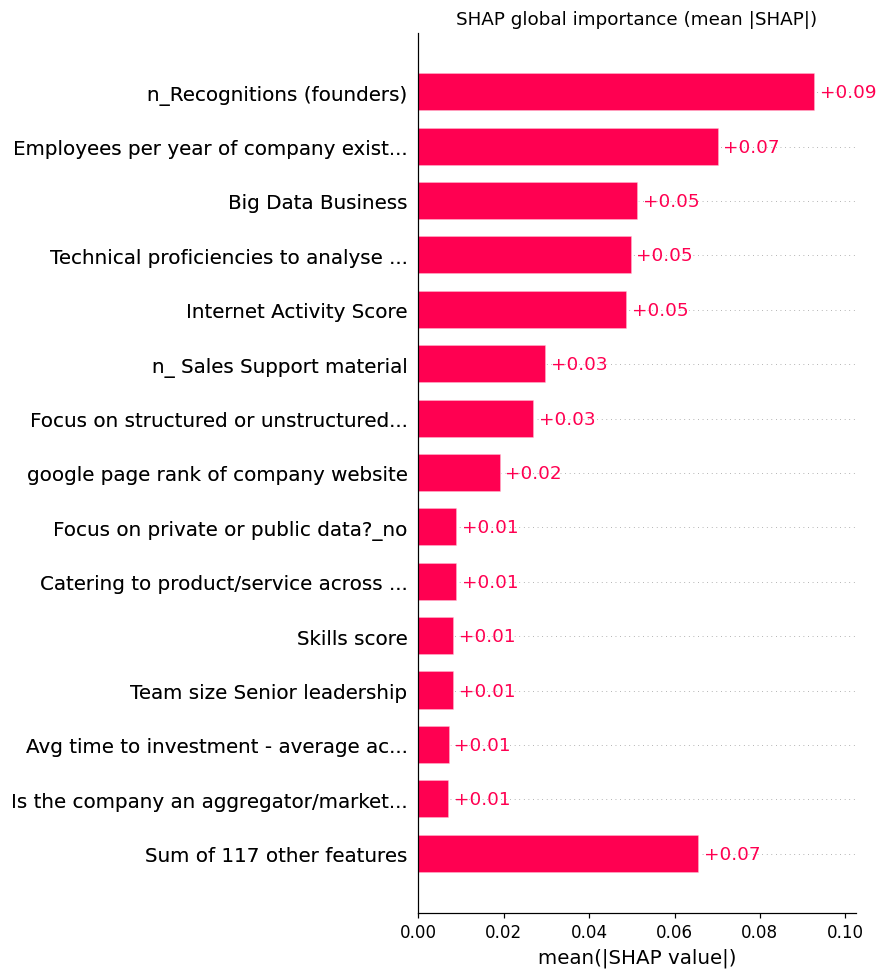

In [25]:
shap.plots.bar(sv, max_display=15, show=False)
plt.title("SHAP global importance (mean |SHAP|)"); plt.tight_layout(); plt.show()

### 16c. Beeswarm - the signature plot (dot per company, colour = feature value)

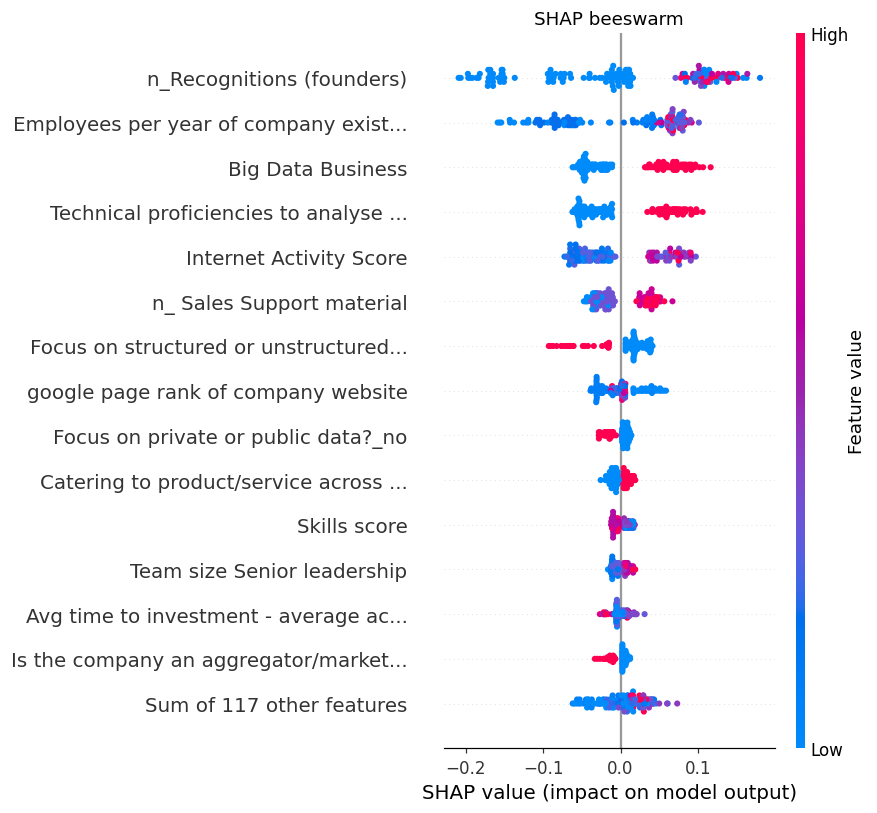

In [26]:
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title("SHAP beeswarm"); plt.tight_layout(); plt.show()

### 16d. Dependence - effect shape of the top feature (approx a PDP)

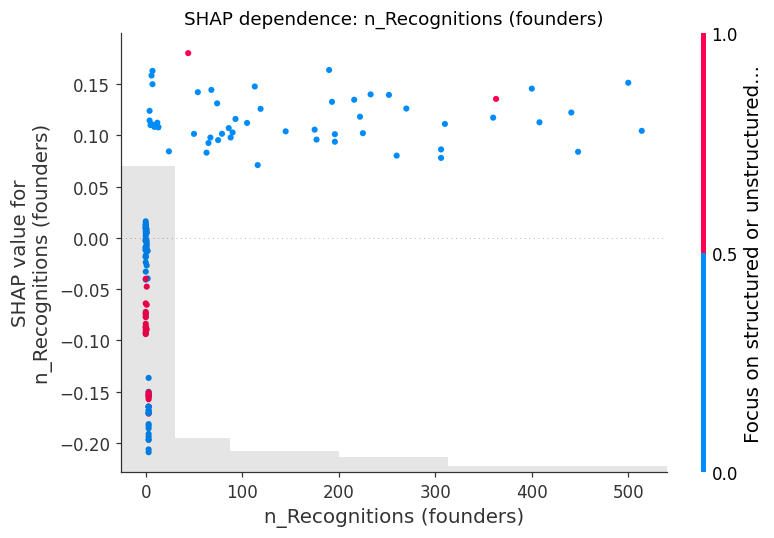

In [27]:
topf = int(np.argmax(np.abs(sv.values).mean(0)))
shap.plots.scatter(sv[:, topf], color=sv, show=False)
plt.title(f"SHAP dependence: {sv.feature_names[topf]}"); plt.tight_layout(); plt.show()

## 17. Deck 3 - LIME on the same company

LIME fits a simple local surrogate around one prediction. Compare its top features to SHAP's for
the same startup - they broadly agree, but LIME is less stable.

In [28]:
from lime.lime_tabular import LimeTabularExplainer
lime_exp = LimeTabularExplainer(Xtr_g.values, feature_names=[shorten(back[c]) for c in gnames],
                                class_names=["Fail", "Success"], discretize_continuous=True,
                                random_state=SEED)
exp = lime_exp.explain_instance(Xte_g.values[i], best.predict_proba, num_features=8)
print(f"LIME explanation for company #{i}:")
for feat_desc, w in exp.as_list():
    print(f"  {w:+.3f}  {feat_desc}")

LIME explanation for company #53:
  -0.131  Big Data Business <= 0.00
  +0.110  3.00 < n_Recognitions (founders) <= 80.50
  +0.109  Focus on structured or unstructured... <= 0.00
  -0.107  Technical proficiencies to analyse ... <= 0.00
  -0.074  0.00 < Internet Activity Score <= 60.00
  -0.064  n_ Sales Support material <= 1.00
  +0.040  Continent of company_South America <= 0.00
  +0.039  Is the company an aggregator/market... <= 0.00


## 18. Deck 3 - counterfactual recourse (DiCE)

For a startup the tuned model predicts will fail, what is the smallest **actionable** change that
would flip it to predicted-success? We let only founder-controllable levers move (sales material,
technical capability, advisors, co-founders), and freeze the rest.

In [29]:
import dice_ml
train_df = Xtr_g.copy(); train_df["success"] = ytr.values
inv = {v: k for k, v in back.items()}                    # original name -> sanitized (LightGBM) name
# founder-controllable levers the model actually uses, each with a REALISTIC cap so DiCE cannot
# propose nonsense like "hire 3000 employees" (that would violate plausibility + proximity).
LEVERS_ORIG = {
    "Number of  Sales Support material": (0, 3),
    "Technical proficiencies to analyse and interpret unstructured data": (0, 1),
    "Number of of advisors": (0, 8),
    "Number of Co-founders": (1, 5),
}
LEVERS = {inv[c]: b for c, b in LEVERS_ORIG.items() if c in inv}
actionable = list(LEVERS)
permitted = {c: [float(lo), float(hi)] for c, (lo, hi) in LEVERS.items()}

d = dice_ml.Data(dataframe=train_df, continuous_features=gnames, outcome_name="success")
m = dice_ml.Model(model=best, backend="sklearn")
dice = dice_ml.Dice(d, m, method="random")
print("actionable levers:", [shorten(back[c]) for c in actionable])

# search predicted-fail companies (our focus #i first, then others closest to the line)
order = [i] + [int(j) for j in fail_idx[np.argsort(-p_s[fail_idx])] if int(j) != i]
found = None
for j in order[:25]:
    q = Xte_g.iloc[[j]]
    try:
        cf = dice.generate_counterfactuals(q, total_CFs=5, desired_class="opposite",
                                           features_to_vary=actionable, permitted_range=permitted,
                                           random_seed=SEED)
        cands = cf.cf_examples_list[0].final_cfs_df
    except Exception:
        continue
    if cands is None or len(cands) == 0:
        continue
    for _, row in cands.iterrows():                       # round levers to whole units; keep flips that survive
        cand, changed = q.copy(), {}
        for c in actionable:
            new = min(max(int(round(float(row[c]))), int(LEVERS[c][0])), int(LEVERS[c][1]))
            old = int(round(float(q.iloc[0][c])))
            if new != old:
                cand.iat[0, cand.columns.get_loc(c)] = new
                changed[c] = (old, new)
        if 1 <= len(changed) <= 3 and best.predict_proba(cand[gnames].astype(float))[0, 1] >= 0.5:
            found = (j, float(p_s[j]), float(best.predict_proba(cand[gnames].astype(float))[0, 1]), changed)
            break
    if found:
        break

if found:
    j, p0, p1, changed = found
    print(f"\nCompany #{j}: predicted fail (p_success={p0:.2f}). Smallest realistic actionable change that flips it:")
    for c, (o, n) in changed.items():
        print(f"  {shorten(back[c])}: {o}  ->  {n}")
    print(f"  => p_success {p0:.2f} -> {p1:.2f}  (crosses the 0.5 decision line)")
else:
    print("No small, realistic, founder-controllable change flips these companies - the model leans on")
    print("features the founder cannot act on. An honest (if unsatisfying) recourse result worth stating.")

actionable levers: ['n_ Sales Support material', 'Technical proficiencies to analyse ...', 'n_of advisors', 'n_Co-founders']


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.19it/s]

100%|██████████| 1/1 [00:00<00:00,  2.18it/s]


Company #53: predicted fail (p_success=0.41). Smallest realistic actionable change that flips it:
  n_ Sales Support material: 1  ->  2
  Technical proficiencies to analyse ...: 0  ->  1
  => p_success 0.41 -> 0.77  (crosses the 0.5 decision line)


## 19. Synthesis - same data, several rankings

The four importance methods, side by side. They **disagree** - not because any is wrong, but because
each measures a different thing (a linear effect, impurity reduction, permutation loss, Shapley
attribution on the boosted model). This is deck 3's punchline on a real dataset.

In [30]:
rankings = pd.DataFrame({
    "logistic |coef|": coef.abs().sort_values(ascending=False).head(6).index.map(shorten),
    "RF impurity": imp.head(6).index.map(shorten),
    "PFI (test)": pfi.sort_values(ascending=False).head(6).index.map(shorten),
    "SHAP (tuned LGBM)": pd.Series(np.abs(sv.values).mean(0), index=safe_cols).sort_values(ascending=False).head(6).index.map(shorten),
}).reset_index(drop=True)
rankings.index = [f"#{k+1}" for k in range(len(rankings))]
rankings

,logistic |coef|,RF impurity,PFI (test),SHAP (tuned LGBM)
#1,recession_survival_No,Internet Activity Score,Internet Activity Score,n_Recognitions (founders)
#2,Time to market service or product,n_Recognitions (founders),Employees per year of company exist...,Employees per year of company exist...
#3,Worked in top companies,Big Data Business,recession_survival_Not Applicable,Big Data Business
#4,Is the company an aggregator/market...,google page rank of company website,Technical proficiencies to analyse ...,Technical proficiencies to analyse ...
#5,Continent of company_Asia,recession_survival_Not Applicable,google page rank of company website,Internet Activity Score
#6,Big Data Business,Technical proficiencies to analyse ...,n_ Sales Support material,n_ Sales Support material


## 20. Conclusions

- **Interpretability is an audit tool.** The naive forest hit ~0.95 AUC, but PFI/SHAP showed it
  leaning on **leakage / hindsight** features (recession survival, internet activity, page rank).
  Removing one leak barely moved AUC - leakage was distributed, and only the ranking exposed it.
- **A tuned model is not automatically a better one.** Bayesian optimization (Optuna/TPE) pushed the
  LightGBM's *CV* AUC to ~0.97, but its *test* AUC sat within noise of the forest - on 472 rows,
  model choice matters far less than fixing leakage, and TreeSHAP made the boosted model just as
  interpretable as the forest.
- **Important != causal.** "Part of a successful startup before" and social-media activity correlate
  with success, but a founder cannot *cause* success by editing those fields. PFI/SHAP tell you what
  the *model uses*, not what moves the world.
- **Importance is method-dependent.** The four rankings above disagree; always say *which* importance,
  on *what* data (test), for *which* model.
- **Caveats.** 472 rows x ~130 features is a small-n/high-p regime, so importances are noisy (wide PFI
  error bars) and the dataset itself is subjective and messy. Treat the "drivers" as hypotheses to
  test, not findings - which is exactly the honest posture interpretability is meant to enforce.